Imports y paths

In [40]:
import pandas as pd
import numpy as np
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_FEATURES_DIR = Path("../../../data/features/hotel_ttoo")
OUTPUT_DIR        = Path("../../../models/forecast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Cargar dataset

In [41]:
DATA_PATH = DATA_FEATURES_DIR / "HOTEL_1.parquet"

df = pd.read_parquet(DATA_PATH)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").set_index("fecha")

print("Rango HOTEL_1:", df.index.min(), "→", df.index.max())

season_cols = [c for c in df.columns if c.startswith("season_")]

if "season" in df.columns and not season_cols:
    print("✅ Generando season_*...")
    df = pd.get_dummies(df, columns=["season"], prefix="season", drop_first=False)

for c in df.columns:
    if c.startswith("season_"):
        df[c] = df[c].astype(int)

print("Columnas season_*:", [c for c in df.columns if c.startswith("season_")])

FEATURES = (
    [c for c in df.columns if c.startswith("rn_")] +
    [c for c in df.columns if c.startswith("season_")] +
    ["is_weekend"]
)

TARGET = "ocup_total"

df = df[[TARGET] + FEATURES].dropna()

Rango HOTEL_1: 2023-01-01 00:00:00 → 2025-10-20 00:00:00
✅ Generando season_*...
Columnas season_*: ['season_autumn', 'season_spring', 'season_summer', 'season_winter']


Split temporal

In [42]:
df_train = df[df.index < "2026-01-01"].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]

scaler  = StandardScaler()
num_cols = [c for c in FEATURES if c.startswith("rn_")]

X_train_scaled = X_train.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

Modelo Xgboost

In [43]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse"
)

model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Horizonte de forecast

In [44]:
future_index = pd.date_range(
    start=df_train.index[-1] + pd.Timedelta(days=1),
    end=df_train.index[-1] + pd.Timedelta(days=365),
    freq="D"
)

Escenario BAU

In [45]:
last30   = df_train[FEATURES].tail(30)
BAU      = last30.mean().to_frame().T

future_BAU = pd.concat([BAU] * len(future_index), ignore_index=True)
future_BAU.index = future_index

future_BAU["is_weekend"] = (future_BAU.index.dayofweek >= 5).astype(int)

Escenario estacional 

In [46]:
future_EST = pd.DataFrame(index=future_index, columns=FEATURES)

for d in future_index:
    match = df_train[
        (df_train.index.month == d.month) &
        (df_train.index.day   == d.day)
    ]
    if len(match):
        future_EST.loc[d] = match[FEATURES].iloc[-1]
    else:
        future_EST.loc[d] = BAU.iloc[0]

future_EST["is_weekend"] = (future_EST.index.dayofweek >= 5).astype(int)

ESCENARIO 1 — REFORZAR OTA EN INVIERNO

In [47]:
CUPO_EXTRA = 0.20
CUPO_REDUCCION = 0.15
SHIFT_RATIO = 0.20

In [48]:
future_OTA_PUSH_WINTER = future_EST.copy()
mask_winter = (future_OTA_PUSH_WINTER["season_winter"] == 1)
future_OTA_PUSH_WINTER.loc[mask_winter, ["rn_B", "rn_WEL"]] *= (1 + CUPO_EXTRA)

ESCENARIO 2 — REDUCIR OTA EN VERANO

In [49]:
future_OTA_CAP_SUMMER = future_EST.copy()
mask_summer = (future_OTA_CAP_SUMMER["season_summer"] == 1)
future_OTA_CAP_SUMMER.loc[mask_summer, ["rn_B", "rn_WEL"]] *= (1 - CUPO_REDUCCION)

ESCENARIO 3 — REDISTRIBUIR INVENTARIO ENTRE OTAs (B -> EX)

In [50]:
future_MIX_SHIFT = future_EST.copy()
future_MIX_SHIFT["rn_B"]  *= (1 - SHIFT_RATIO)
future_MIX_SHIFT["rn_EX"] *= (1 + SHIFT_RATIO)

ESCENARIO 4 - REFORZAR OTA EN DÍAS FLOJOS DE OCUPACIÓN (VALLES)

In [51]:
future_LOW_PROTECTION = future_EST.copy()

low_threshold = df_train[TARGET].quantile(0.4)
hist_low_days = df_train[df_train[TARGET] < low_threshold]
low_days      = hist_low_days.index.dayofyear.unique()

mask_low = future_LOW_PROTECTION.index.dayofyear.isin(low_days)
future_LOW_PROTECTION.loc[mask_low, ["rn_B", "rn_WEL"]] *= (1 + CUPO_EXTRA)

In [52]:
def fix_season_columns(df_future):
    for c in df_future.columns:
        if c.startswith("season_"):
            df_future[c] = df_future[c].astype(int)
    return df_future

future_BAU             = fix_season_columns(future_BAU)
future_EST             = fix_season_columns(future_EST)
future_OTA_PUSH_WINTER = fix_season_columns(future_OTA_PUSH_WINTER)
future_OTA_CAP_SUMMER  = fix_season_columns(future_OTA_CAP_SUMMER)
future_MIX_SHIFT       = fix_season_columns(future_MIX_SHIFT)
future_LOW_PROTECTION  = fix_season_columns(future_LOW_PROTECTION)

Escalado

In [53]:
def scale_future(df_future):
    df_scaled = df_future.copy()
    df_scaled[num_cols] = scaler.transform(df_future[num_cols])
    return df_scaled

Forecast con intervalos

In [54]:
def forecast_xgb(df_future):
    X      = scale_future(df_future[FEATURES])
    y_pred = model.predict(X)
    y_pred = np.clip(y_pred, 0, 1)
    return pd.DataFrame({"y_pred": y_pred}, index=df_future.index)

Dataset final

In [55]:
def tag(df_fc, scenario):
    df_fc = df_fc.copy()
    df_fc["scenario"] = scenario
    df_fc["hotel"]    = "HOTEL_1"
    return df_fc

fc_BAU             = tag(forecast_xgb(future_BAU),             "BAU")
fc_EST             = tag(forecast_xgb(future_EST),             "ESTACIONAL")
fc_OTA_PUSH_WINTER = tag(forecast_xgb(future_OTA_PUSH_WINTER), "OTA_PUSH_WINTER")
fc_OTA_CAP_SUMMER  = tag(forecast_xgb(future_OTA_CAP_SUMMER),  "OTA_CAP_SUMMER")
fc_MIX_SHIFT       = tag(forecast_xgb(future_MIX_SHIFT),       "MIX_SHIFT_EX")
fc_LOW_PROTECTION  = tag(forecast_xgb(future_LOW_PROTECTION),  "LOW_DEMAND_PROTECTION")

df_forecast = pd.concat([
    fc_BAU,
    fc_EST,
    fc_OTA_PUSH_WINTER,
    fc_OTA_CAP_SUMMER,
    fc_MIX_SHIFT,
    fc_LOW_PROTECTION,
])

df_forecast = df_forecast.reset_index().rename(columns={"index": "fecha"})

Dataset final

In [56]:
df_forecast.to_parquet(OUTPUT_DIR / "forecast_HOTEL_1.parquet", index=False)
print("✅ Forecast HOTEL_1 guardado.")

✅ Forecast HOTEL_1 guardado.


Visualización

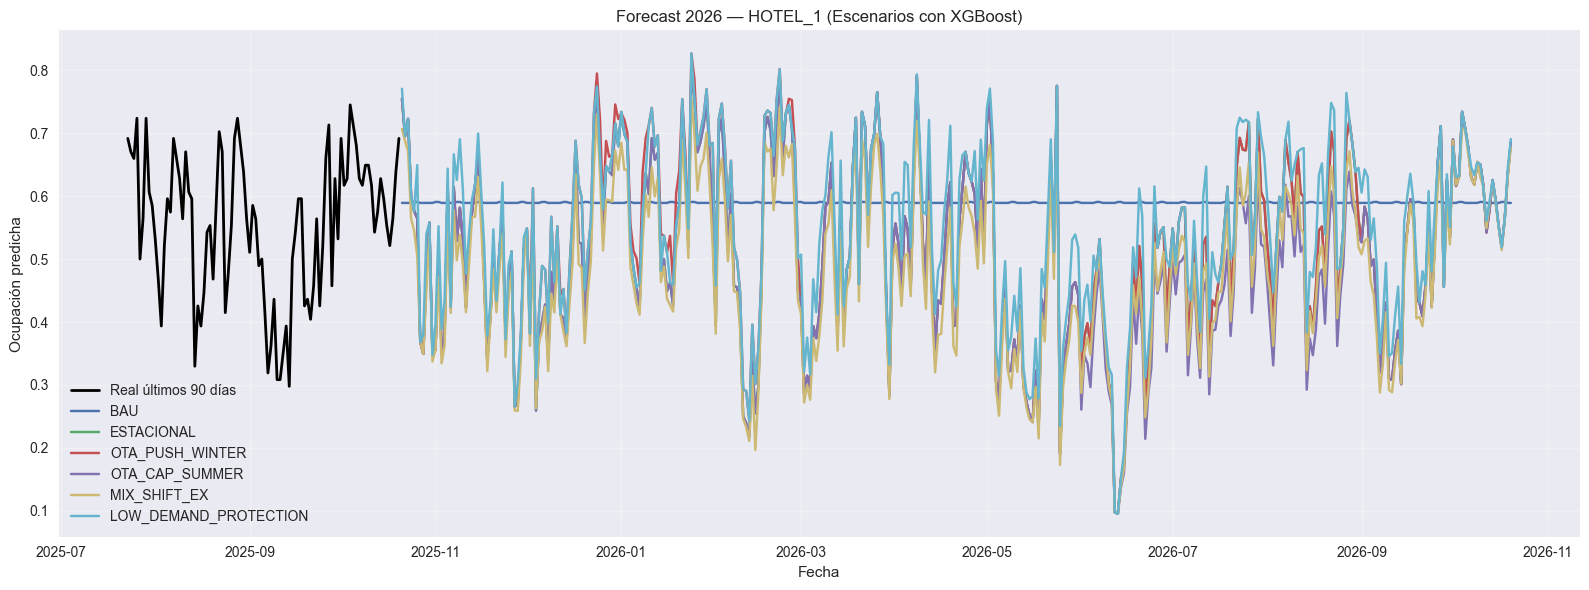

In [57]:
df_forecast["fecha"] = pd.to_datetime(df_forecast["fecha"], unit="ms")
df_forecast = df_forecast.set_index("fecha")

plt.figure(figsize=(16, 6))

plt.plot(
    df_train.tail(90).index,
    df_train.tail(90)[TARGET],
    color="black", lw=2,
    label="Real últimos 90 días"
)

for scenario in df_forecast["scenario"].unique():
    subset = df_forecast[df_forecast["scenario"] == scenario]
    plt.plot(subset.index, subset["y_pred"], label=scenario)

plt.title("Forecast 2026 — HOTEL_1 (Escenarios con XGBoost)")
plt.xlabel("Fecha")
plt.ylabel("Ocupación predicha")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión del Forecast Multiescenario — Hotel 1
### XGBoost + Escenarios de Revenue Management Realistas

El forecast 2026 del Hotel 1 se construye sobre el modelo final seleccionado en la fase de modelado: **XGBoost**, que ha demostrado el mejor rendimiento predictivo (MAE ≈ 0.052) y una elevada capacidad para capturar la relación entre ocupación diaria y actividad por canal (`rn_*`), especialmente en el entorno OTA (canales B y WEL).

A partir de este modelo se han diseñado **escenarios WHAT‑IF realistas**, basados exclusivamente en **decisiones operativas que un hotel urbano puede ejecutar en la práctica**, dentro de un marco real de Revenue Management:

- gestión de cupos por canal,
- priorización de distribución,
- optimización en periodos valle,
- control de dependencia en picos de demanda.

Todas las simulaciones respetan estrictamente el pipeline causal del proyecto: `rn_*` (actividad por canal, variable accionable vía cupos), `season_*` (contexto temporal) e `is_weekend` (patrón operativo urbano).

**En ningún escenario se modifica la demanda del mercado.** El hotel no "crea" clientes: únicamente decide cómo distribuye su inventario disponible.

---

## Aportación del análisis SHAP temporal en el Hotel 1

Además de las métricas de error y el SHAP global, se incorpora un **análisis SHAP temporal** para el Hotel 1, con el objetivo de entender cuándo los canales OTA realmente influyen en la ocupación y por qué los escenarios presentan impactos limitados.

El SHAP temporal muestra que:

- los canales B y WEL tienen **impacto positivo intermitente**, dependiente del contexto diario,
- no existen regímenes largos de influencia positiva sostenida,
- y la elasticidad se concentra en **días concretos**, no en periodos estacionales completos.

Esto confirma que el Hotel 1 es un hotel **urbano con micro‑oportunidades tácticas**, donde la gestión debe ser selectiva y defensiva, no estructural, explicando de forma natural los resultados observados en los escenarios de forecast.

Este patrón implica que las decisiones de Revenue en el Hotel 1 **no deben basarse en refuerzos sostenidos por temporada**, sino en actuaciones selectivas sobre días concretos con margen de mejora.

---

## Análisis detallado de escenarios (WHAT‑IF)

### 1. BAU — *Business As Usual*

**Qué representa:** escenario inercial — el hotel mantiene exactamente la misma estrategia actual, sin cambios en cupos ni en priorización de canales.

**Resultado:** ocupación estable en torno a 0.58–0.60, con variabilidad muy baja.

**Conclusión clave:** el Hotel 1 presenta un comportamiento **estructuralmente estable**, típico de un hotel urbano con demanda constante. La ocupación depende más del entorno de mercado que de acciones tácticas agresivas. El SHAP temporal confirma que, en ausencia de intervención táctica, la contribución de las OTAs oscila alrededor de cero en la mayor parte del calendario.

---

### 2. ESTACIONAL — *Reproducción del patrón histórico*

**Qué representa:** escenario de memoria histórica — "si el año que viene se comporta como los años anteriores en las mismas fechas".

**Resultado:** mayor variabilidad que BAU, con aparición de micro‑picos y micro‑valles.

**Conclusión clave:** el Hotel 1 **no es un hotel estacional** en sentido clásico, pero sí presenta **patrones urbanos reales**, moderados y consistentes.

---

### 3. OTA_PUSH_WINTER — *Refuerzo OTA en invierno*

**Qué representa:** decisión habitual de Revenue Management — "abrir más cupo en OTAs durante periodos de demanda floja".

**Resultado:** mejora ligera en periodos valle, con incremento contenido de la ocupación.

**Conclusión clave:** el refuerzo OTA permite **capturar mejor la demanda existente**, pero no transforma el comportamiento del hotel. La elasticidad invernal es **limitada**, coherente con un hotel urbano estable. El SHAP temporal muestra señales positivas aisladas en invierno, pero sin continuidad suficiente como para generar un cambio estructural.

---

### 4. OTA_CAP_SUMMER — *Limitación OTA en verano*

**Qué representa:** estrategia común en hoteles urbanos — "reducir dependencia de OTA cuando la demanda ya es alta".

**Resultado:** ligera caída de ocupación en picos, sin caídas bruscas ni colapsos.

**Conclusión clave:** en periodos de alta demanda, el Hotel 1 puede **reducir dependencia de OTA sin una penalización significativa**. Esto abre una palanca real de **mejora de margen**, no de crecimiento. El SHAP temporal muestra que, en contextos de ocupación elevada, la contribución marginal de B y WEL tiende a neutralizarse, legitimando una estrategia de reducción de dependencia sin riesgo operativo.

---

### 5. MIX_SHIFT_EX — *Redistribución del mix OTA*

**Qué representa:** simula un cambio entre plataformas — "mover inventario del canal B hacia EX".

**Resultado:** impacto prácticamente neutro, con curva casi idéntica al escenario base.

**Conclusión clave:** el Hotel 1 presenta **baja sensibilidad al mix entre plataformas OTA**: los canales son altamente intercambiables y la demanda urbana online está consolidada. El SHAP global y temporal refuerzan que la sustitución entre OTAs es **altamente compensatoria**, validando este escenario como caso de contraste, no como palanca real.

---

### 6. LOW_DEMAND_PROTECTION — *Protección inteligente de baja demanda*

**Qué representa:** estrategia avanzada de Revenue — "actuar solo cuando sé que el día va a ser malo".

**Resultado:** mejora puntual de valles, con reducción ligera de caídas extremas.

**Conclusión clave:** es el **escenario más eficiente estratégicamente**: suaviza la curva de ocupación, mejora consistencia operativa y no infla picos ni aumenta costes innecesarios. El SHAP temporal muestra que las OTAs tienen impacto positivo precisamente en **días débiles aislados**, lo que convierte este escenario en el **más alineado con el comportamiento real del hotel**.

---

## Conclusión global del Forecast Hotel 1

**El Hotel 1 es un hotel estructuralmente estable.** La ocupación se mantiene en un rango estrecho (~0.55–0.65) en casi todos los escenarios.

**La elasticidad operativa es limitada.** Las decisiones sobre canales generan impactos marginales, no transformacionales.

**OTA domina, pero no condiciona completamente.** Los canales B y WEL estabilizan la demanda, pero no generan grandes palancas de crecimiento.

**El valor está en optimizar, no en crecer agresivamente.** Las estrategias más útiles son optimizar valles (`LOW_DEMAND_PROTECTION`) y reducir costes en picos (`OTA_CAP_SUMMER`).

**Estrategia recomendada para el Hotel 1:**

- reforzar OTA solo en baja ocupación,
- limitar OTA en picos para mejorar margen,
- no sobreinvertir en cambios de mix entre plataformas,
- aprovechar la estabilidad como ventaja competitiva.

---

## Realismo de los escenarios

Los escenarios simulados representan **decisiones reales de Revenue Management**: apertura o cierre de cupos por canal, priorización de OTAs según periodo, y optimización táctica en días de baja ocupación. En ningún caso se altera la demanda externa, sino únicamente la **oferta controlada por el hotel**.

Los escenarios del Hotel 1 están **validados por el análisis SHAP**, que demuestra que no existen palancas estructurales comparables a hoteles vacacionales, que la gestión más eficiente es táctica, selectiva y defensiva, y que los impactos obtenidos son consistentes con la naturaleza urbana del hotel.

---

## Conclusión final

El forecast multiescenario del Hotel 1 no busca maximizar artificialmente la ocupación, sino **identificar con precisión cuándo actuar, dónde actuar y con qué impacto realista**.

La combinación de XGBoost, SHAP global y SHAP temporal permite entender tanto el potencial como los límites de la gestión por canal, posicionando al Hotel 1 como el caso urbano de referencia del proyecto, frente a los hoteles vacacionales (Hotel 2 y Hotel 3).